In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import VotingClassifier

In [145]:
dataset = pd.read_csv('heart.csv')
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


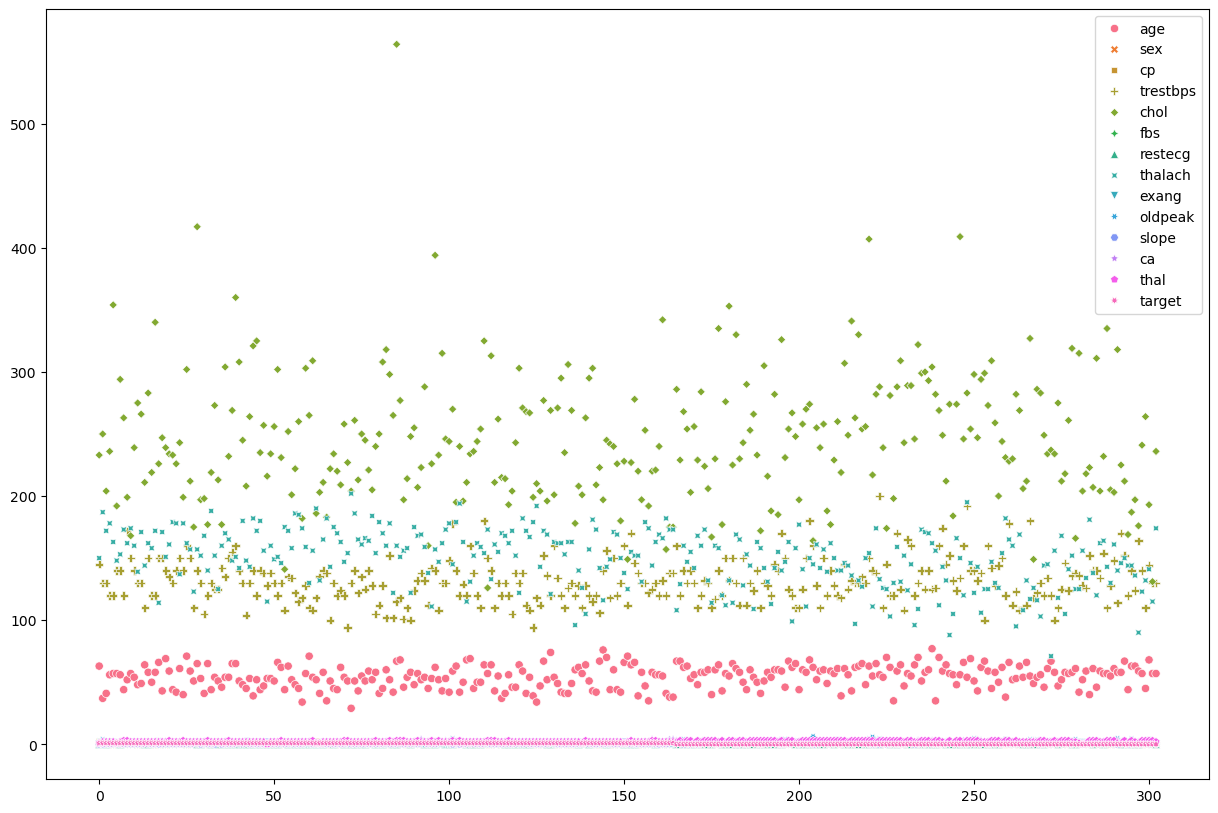

In [13]:
plt.figure(figsize = (15,10))
sns.scatterplot(data = dataset)
plt.show()

In [6]:
x = dataset.iloc[:,:-1]
y = dataset['target']

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 67)

In [8]:
lr = LogisticRegression(random_state=39, C=1.0, l1_ratio=0.1)
lr.fit(x_train, y_train)

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,39
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
lr.score(x_train, y_train)*100,lr.score(x_test, y_test)*100

(86.32075471698113, 80.21978021978022)

In [10]:
lr.predict(x_test)

array([0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0])

In [11]:
confusion_matrix(y_test,lr.predict(x_test))

array([[35, 18],
       [ 0, 38]])

In [12]:
cm = confusion_matrix(y_test,lr.predict(x_test))

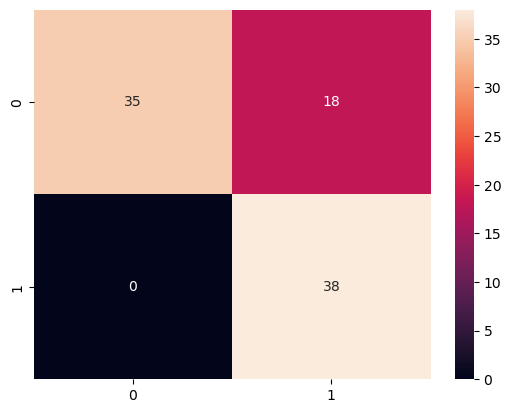

In [13]:
sns.heatmap(cm, annot = True)
plt.show()

In [14]:
lr.predict([[63,1,3,145,233,1,0,150,0,2.3,0,0,1]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

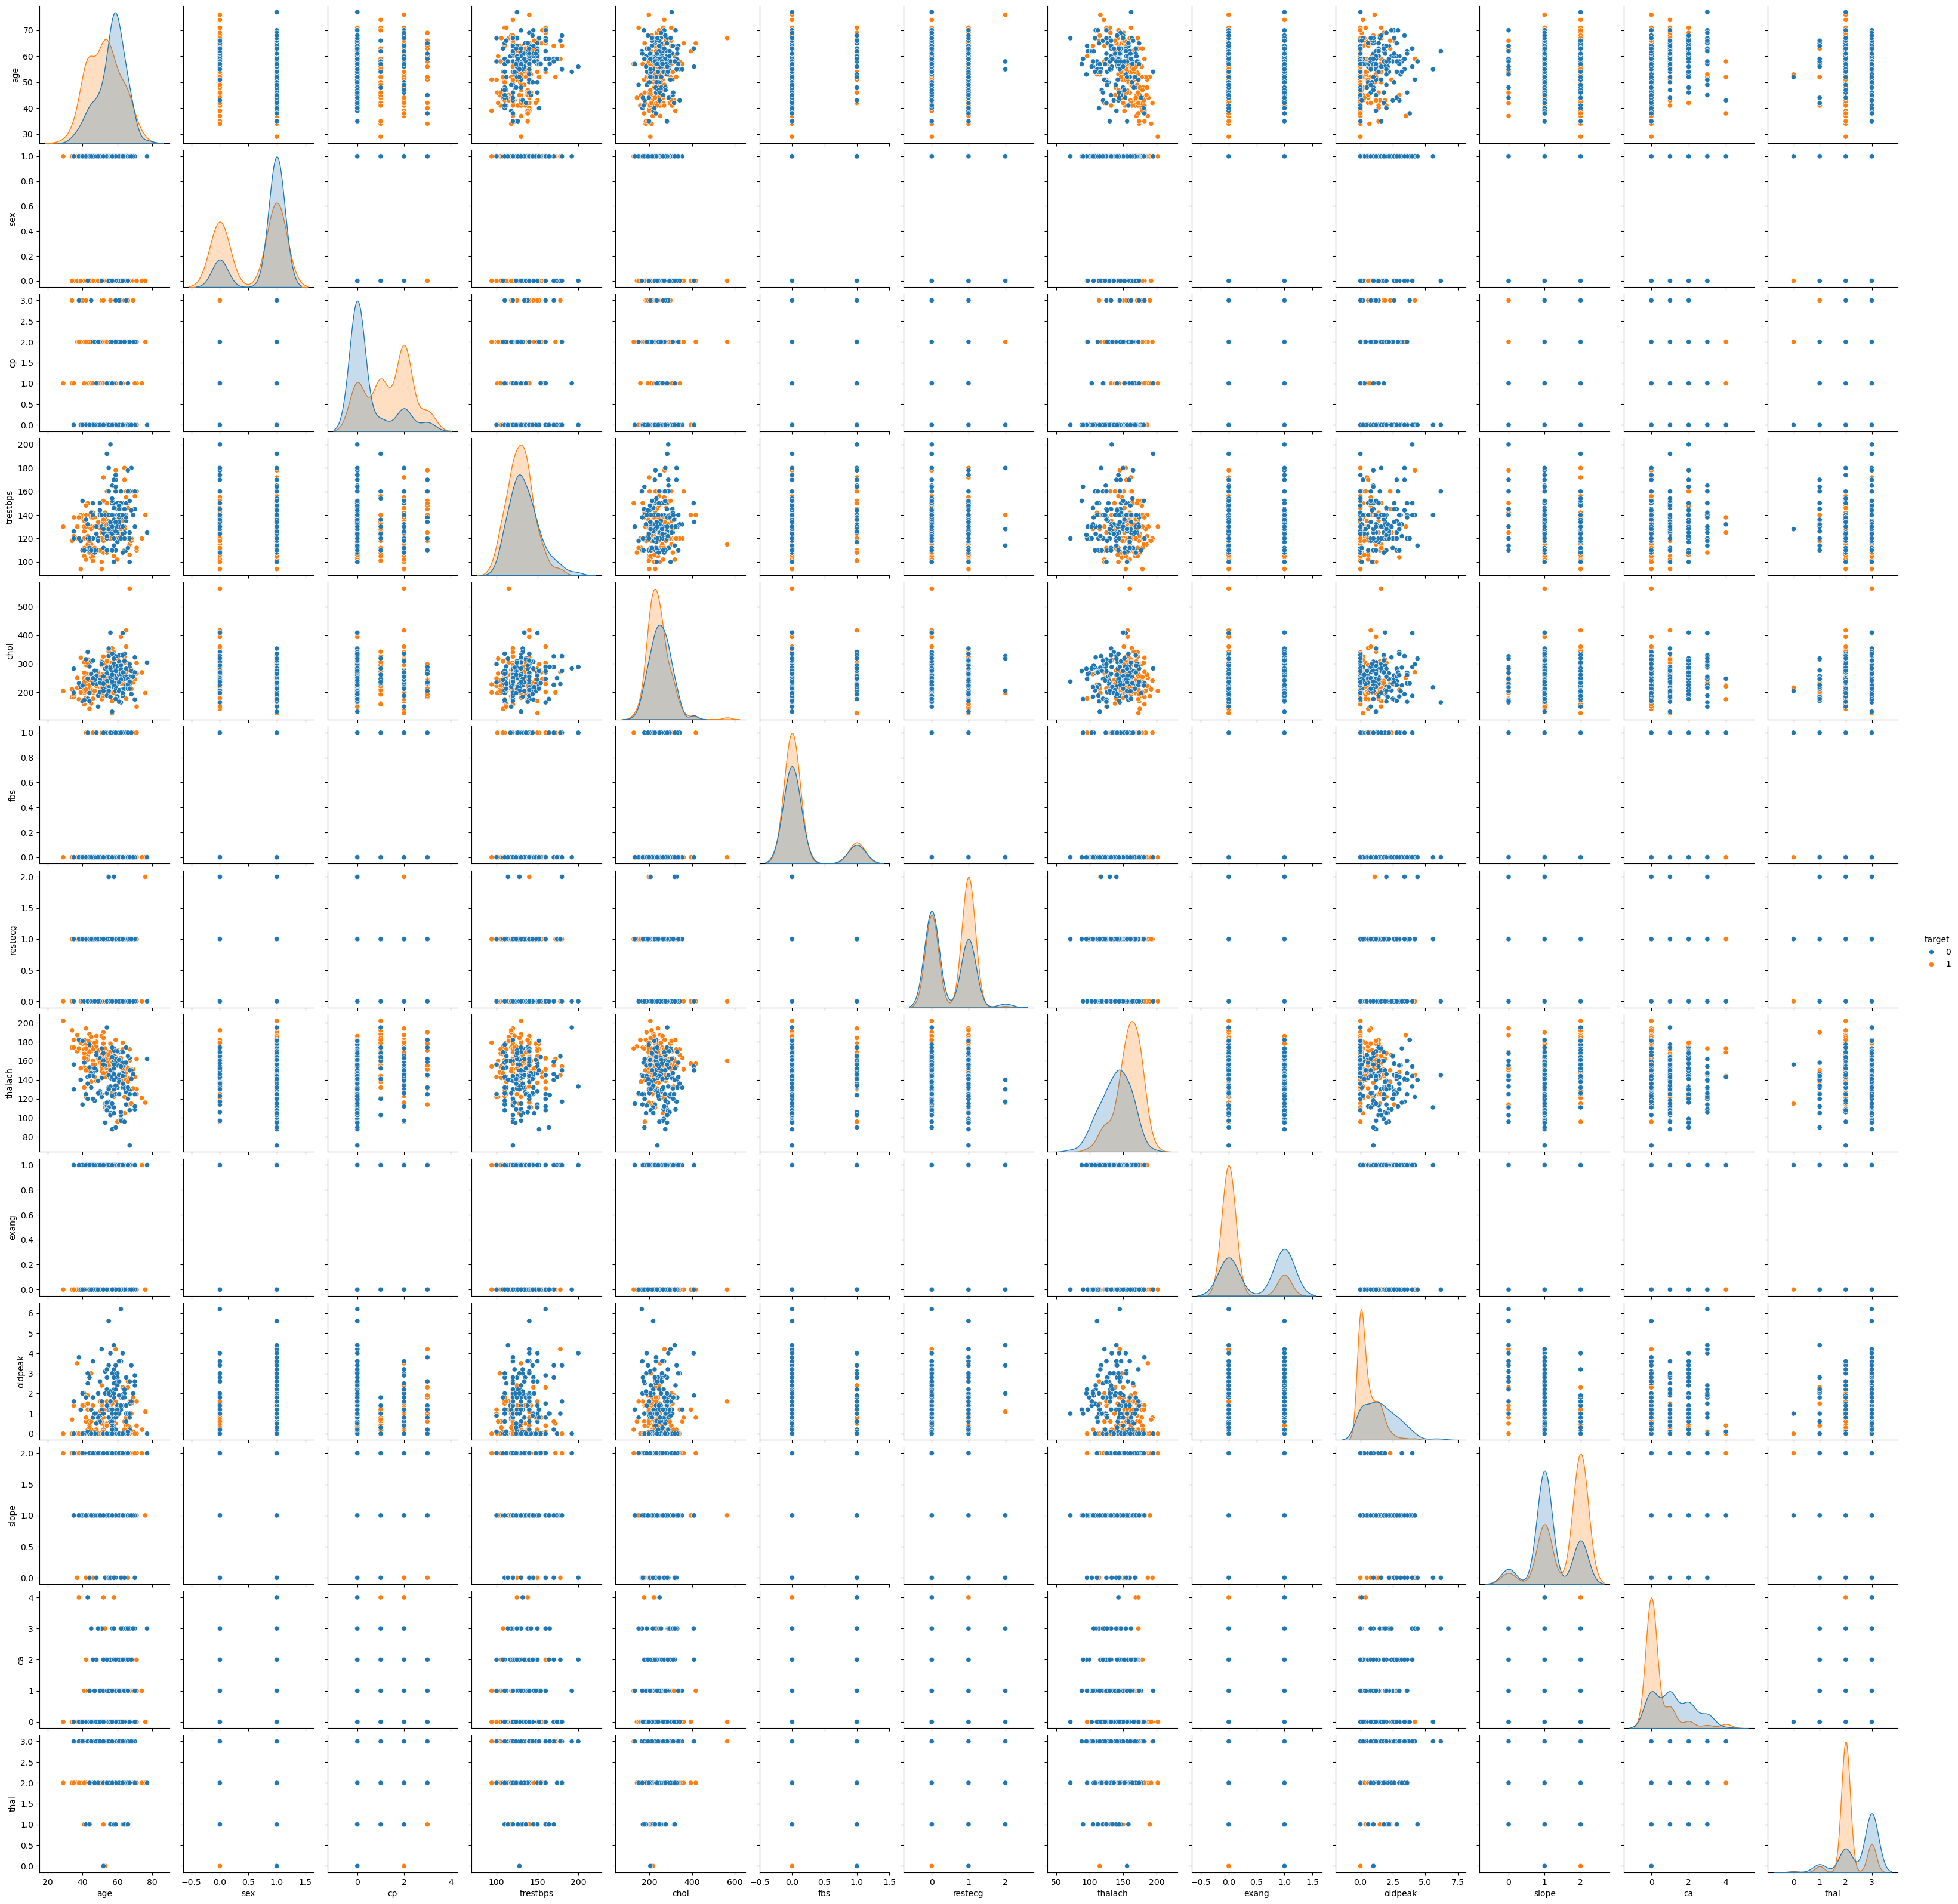

In [16]:
sns.pairplot(data = dataset, hue = 'target')
plt.show()

In [118]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 69)

In [59]:
gb = GaussianNB()
gb.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [92]:
gb.score(x_train, y_train)*100,gb.score(x_test, y_test)*100

(81.81818181818183, 88.52459016393442)

In [108]:
gb.predict(x_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [119]:
confusion_matrix(y_test, gb.predict(x_test))

array([[26,  3],
       [ 3, 29]])

In [120]:
cf = confusion_matrix(y_test, gb.predict(x_test))

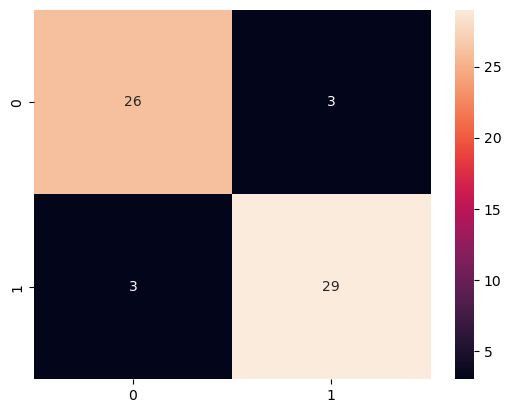

In [121]:
sns.heatmap(cf, annot = True)
plt.show()

In [24]:
gb.predict([[48,0,2,130,275,0,1,139,0,0.2,2,0,2]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])

In [25]:
gb.predict([[61,1,0	,140,207,0,0,138,1,1.9,2,1,3]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([0])

In [128]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 39)

In [123]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [124]:
dt.score(x_train, y_train)*100,dt.score(x_test, y_test)*100

(100.0, 76.92307692307693)

In [125]:
dt.predict(x_train)

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1])

In [129]:
confusion_matrix(y_test, dt.predict(x_test))

array([[35,  2],
       [ 2, 52]])

In [130]:
cfm = confusion_matrix(y_test, dt.predict(x_test))

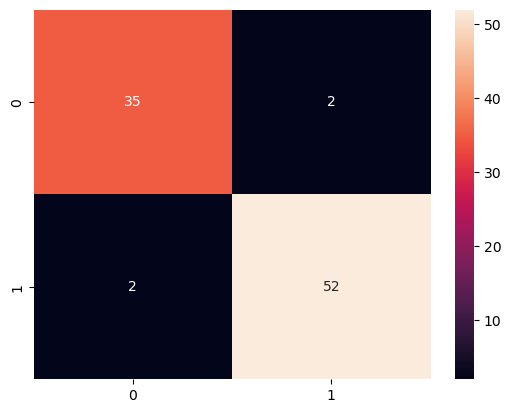

In [131]:
sns.heatmap(cfm, annot = True)
plt.show()


In [132]:
dt.predict([[61,1,0	,140,207,0,0,138,1,1.9,2,1,3]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [133]:
from sklearn.tree import plot_tree

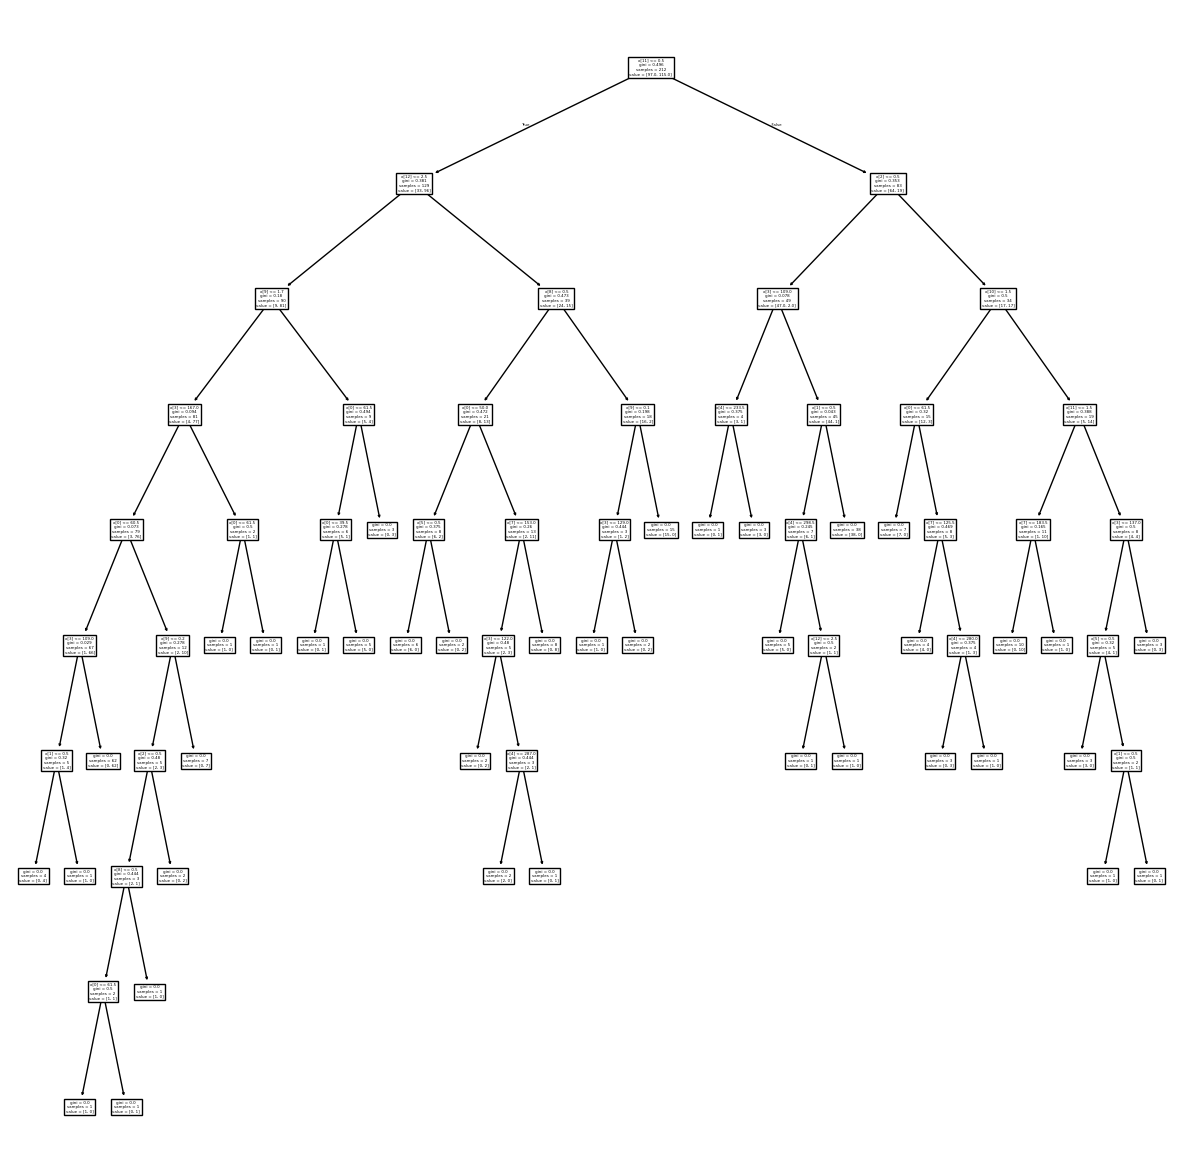

In [134]:
plt.figure(figsize = (15,15))
plot_tree(dt)
plt.show()

In [136]:
ls = [('lr',LogisticRegression()),('dt',DecisionTreeClassifier()),('nb',GaussianNB())]

In [141]:
vc = VotingClassifier(ls)
vc.fit(x_train, y_train)

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [144]:
vc.score(x_train,y_train)*100,vc.score(x_test,y_test)*100

(89.62264150943396, 84.61538461538461)

In [146]:
vc.predict([[57,0,0,120,354,0,1,163,1,0.6,2,0,2]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])

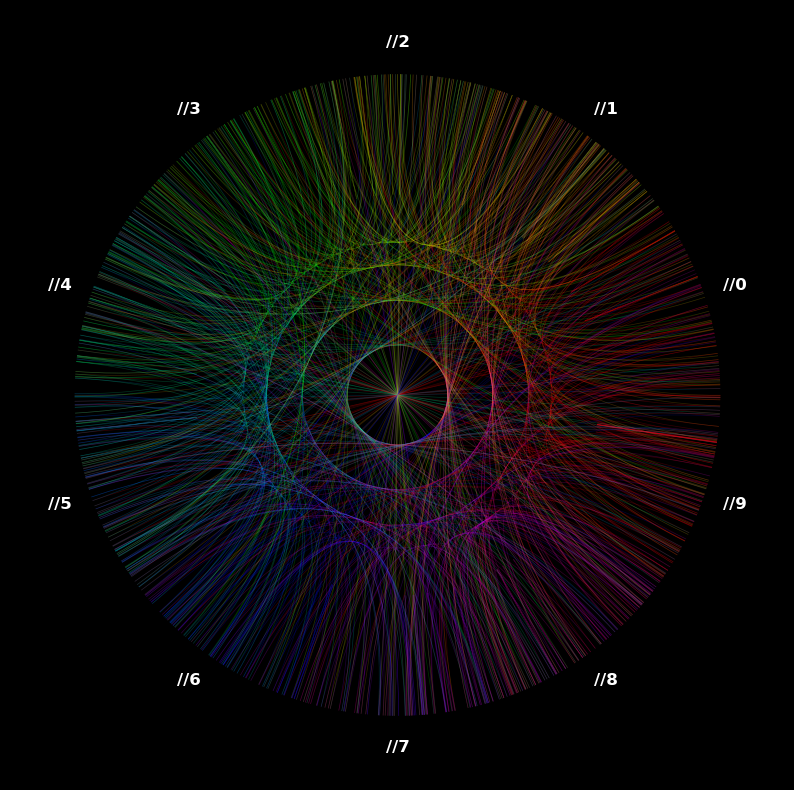

In [155]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches
from mpmath import mp

# 1. Setup Data
# Increase digits for more complexity (e.g., 1000 or 2000)
PRECISION = 1000 
mp.dps = PRECISION
pi_digits = [int(d) for d in str(mp.pi).replace('.', '')]

# 2. Geometry Setup
# Divide the circle into 10 sectors (0-9)
def get_angle(digit, index, total_digits):
    # Base angle for the digit (0-9)
    base_angle = (digit / 10) * 2 * np.pi
    # Add a small offset so lines don't all start at the exact same point
    offset = (index / total_digits) * (2 * np.pi / 10)
    return base_angle + offset

def get_coords(angle, radius=1.0):
    return [radius * np.cos(angle), radius * np.sin(angle)]

# 3. Plotting
fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
ax.set_facecolor('black')

# Color map (matching the rainbow/spectral flow)
colors = plt.cm.hsv(np.linspace(0, 1, 10))

for i in range(len(pi_digits) - 1):
    d1, d2 = pi_digits[i], pi_digits[i+1]
    
    # Get start and end angles
    angle_start = get_angle(d1, i, PRECISION)
    angle_end = get_angle(d2, i+1, PRECISION)
    
    p0 = get_coords(angle_start, radius=1.0) # Start
    p2 = get_coords(angle_end, radius=1.0)   # End
    p1 = [0, 0] # Control point (center) to create the curve
    
    # Create Bézier Curve
    path_data = [
        (Path.MOVETO, p0),
        (Path.CURVE3, p1),
        (Path.CURVE3, p2),
    ]
    codes, verts = zip(*path_data)
    path = Path(verts, codes)
    
    # Draw the line with low alpha (transparency) for the "glow" effect
    patch = patches.PathPatch(path, facecolor='none', edgecolor=colors[d1], 
                              lw=0.5, alpha=0.2)
    ax.add_patch(patch)

# 4. Draw Outer Ring Labels
for d in range(10):
    angle = (d / 10) * 2 * np.pi + (np.pi / 10)
    pos = get_coords(angle, radius=1.1)
    ax.text(pos[0], pos[1], f"//{d}", color='white', fontsize=12, 
            ha='center', va='center', fontweight='bold')

# Final Styling
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axis('off')

plt.show()

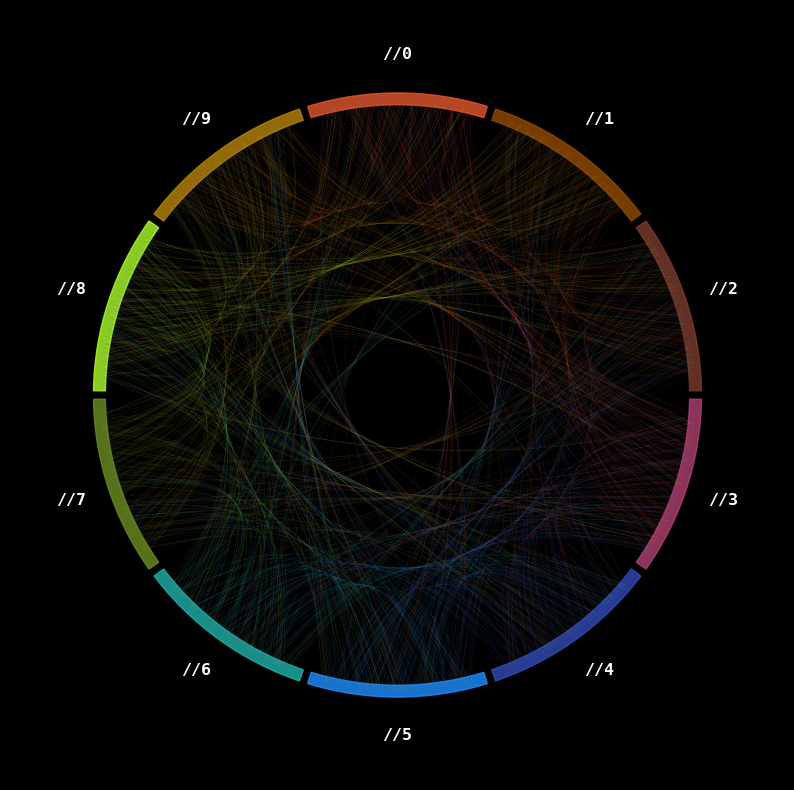

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches

# 1. DATA PREPARATION (First 1000 digits of Pi)
pi_digits_str = "31415926535897932384626433832795028841971693993751058209749445923078164062862089986280348253421170679821480865132823066470938446095505822317253594081284811174502841027019385211055596446229489549303819644288109756659334461284756482337867831652712019091456485669234603486104543266482133936072602491412737245870066063155881748815209209628292540917153643678925903600113305305488204665213841469519415116094330572703657595919530921861173819326117931051185480744623799627495673518857527248912279381830119491298336733624406566430860213949463952247371907021798609437027705392171762931767523846748184676694051320005681271452635608277857713427577896091736371787214684409012249534301465495853710507922796892589235420199561121290219608640344181598136297747713099605187072113499999983729780499510597317328160963185950244594553469083026425223082533446850352619311881710100031378387528865875332083814206171776691473035982534904287554687311595628638823537875937519577818577805321712268066130019278766111959092164201989"
digits = [int(d) for d in pi_digits_str]

# 2. COLOR PALETTE (matching the artistic style)
colors_list = [
    '#e4572e', '#934b00', '#7a3b2e', '#b04173', '#314cb6', 
    '#1e90ff', '#20b2aa', '#6b8e23', '#adff2f', '#b8860b'
]

# 3. GEOMETRY SETUP
# Define sector centers for digits 0-9 starting from the top
sector_centers = np.linspace(np.pi/2, np.pi/2 - 2*np.pi, 11)[:-1]

fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
ax.set_facecolor('black')

radius = 1.0
total_counts = np.array([digits.count(i) for i in range(10)])
current_counts = np.zeros(10, dtype=int)

def get_pos(digit, index_in_digit, total_for_digit):
    """Calculates a unique coordinate for each occurrence of a digit."""
    angle_width = (2 * np.pi / 10) * 0.8  # Use 80% of the sector width
    angle_start = sector_centers[digit] + angle_width / 2
    angle_end = sector_centers[digit] - angle_width / 2
    
    t = index_in_digit / max(1, (total_for_digit - 1))
    angle = angle_start + t * (angle_end - angle_start)
    return angle, np.cos(angle), np.sin(angle)

# 4. DRAW OUTER RING AND LABELS
for d in range(10):
    angle_c = sector_centers[d]
    # Draw the colored segment
    wedge = patches.Wedge((0,0), radius + 0.02, np.degrees(angle_c - 0.3), 
                          np.degrees(angle_c + 0.3), width=0.04, 
                          color=colors_list[d], alpha=0.8)
    ax.add_patch(wedge)
    
    # Draw Label //0, //1, etc.
    lx, ly = (radius + 0.15) * np.cos(angle_c), (radius + 0.15) * np.sin(angle_c)
    ax.text(lx, ly, f"//{d}", color='white', fontsize=12, 
            ha='center', va='center', weight='bold', fontfamily='monospace')

# 5. DRAW CONNECTIONS (The Flow)
positions = []
digit_indices = []
for d in digits:
    angle, x, y = get_pos(d, current_counts[d], total_counts[d])
    positions.append((x, y))
    digit_indices.append(d)
    current_counts[d] += 1

for i in range(len(positions) - 1):
    p1, p2 = positions[i], positions[i+1]
    d_start = digit_indices[i]
    
    # Calculate control point for the curve (pulls towards center)
    p_mid = ((p1[0] + p2[0])/2, (p1[1] + p2[1])/2)
    dist = np.sqrt(p_mid[0]**2 + p_mid[1]**2)
    ctrl_radius = 0.35 # Adjust for the size of the 'hole' in the middle
    p_ctrl = (p_mid[0] * ctrl_radius / dist, p_mid[1] * ctrl_radius / dist) if dist > 0 else (0,0)
        
    path = Path([p1, p_ctrl, p2], [Path.MOVETO, Path.CURVE3, Path.CURVE3])
    patch = patches.PathPatch(path, facecolor='none', edgecolor=colors_list[d_start], 
                              lw=0.4, alpha=0.15)
    ax.add_patch(patch)

# 6. FINAL STYLING
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.axis('off')

plt.show()

#The core logic involves:Sectors: Dividing a circle into 10 segments (0-9).Flow: Connecting each digit of $\pi$ to the next using a Quadratic Bézier Curve.Density: Distributing the start/end points of the lines within each sector to prevent them from overlapping into a single thick line, creating the "flow" effect.